#  Employee Attrition — Predictive ML Model
**Objective:** Build a machine learning model that predicts which employees are most likely to leave, score every active employee by risk level, and calculate the total replacement cost at stake.

**Models used:** Logistic Regression (baseline) + Random Forest (final)

**Output:** A scored employee list with Risk Tier + Replacement Cost — ready for HR action

In [1]:
import os
os.makedirs('plots', exist_ok=True)
os.makedirs('output', exist_ok=True)

In [2]:
pip install scikit-learn matplotlib seaborn

---
## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('HR-Employee-Attrition.csv')
print('Shape:', df.shape)
print('Attrition distribution:')
print(df['Attrition'].value_counts())

Shape: (1470, 35)
Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


---
## 2. Data Preprocessing
Before building any model, we need to:
- Remove useless columns (same value for everyone)
- Encode categorical variables into numbers
- Create the target variable (Attrition = 1 or 0)

In [4]:
# Drop columns with zero variance — they add no signal
df_model = df.copy()
df_model.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Target variable
df_model['Attrition_Flag'] = (df_model['Attrition'] == 'Yes').astype(int)

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Attrition')  # keep original for reference

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Categorical columns encoded:', cat_cols)
print('\nFinal shape:', df_model.shape)
print('\nClass balance:')
print(df_model['Attrition_Flag'].value_counts(normalize=True).round(3))

Categorical columns encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Final shape: (1470, 33)

Class balance:
Attrition_Flag
0    0.839
1    0.161
Name: proportion, dtype: float64


**Note on class imbalance:** 84% stayed, 16% left. This means a model that predicts "nobody leaves" would be 84% accurate — but completely useless. We'll handle this using `class_weight='balanced'` in our models.

---
## 3. Feature & Target Split

In [5]:
# Features: everything except Attrition columns
drop_cols = ['Attrition', 'Attrition_Flag']
X = df_model.drop(columns=drop_cols)
y = df_model['Attrition_Flag']

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')
print(f'\nFeatures used: {X.shape[1]}')
print(f'\nAttrition rate in train: {y_train.mean():.1%}')
print(f'Attrition rate in test:  {y_test.mean():.1%}')

Training set: 1176 rows
Test set:     294 rows

Features used: 31

Attrition rate in train: 16.2%
Attrition rate in test:  16.0%


---
## 4. Baseline Model — Logistic Regression
Always start simple. Logistic Regression gives us a performance floor to beat.

In [6]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Left']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

      Stayed       0.94      0.75      0.84       247
        Left       0.37      0.77      0.50        47

    accuracy                           0.76       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.76      0.78       294

ROC-AUC Score: 0.8029


---
## 5. Final Model — Random Forest
Random Forest handles non-linear relationships and feature interactions better. It also gives us feature importance — critical for business storytelling.

In [7]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

      Stayed       0.85      0.96      0.90       247
        Left       0.38      0.13      0.19        47

    accuracy                           0.83       294
   macro avg       0.61      0.54      0.55       294
weighted avg       0.78      0.83      0.79       294

ROC-AUC Score: 0.7838


---
## 6. Model Comparison — Visual

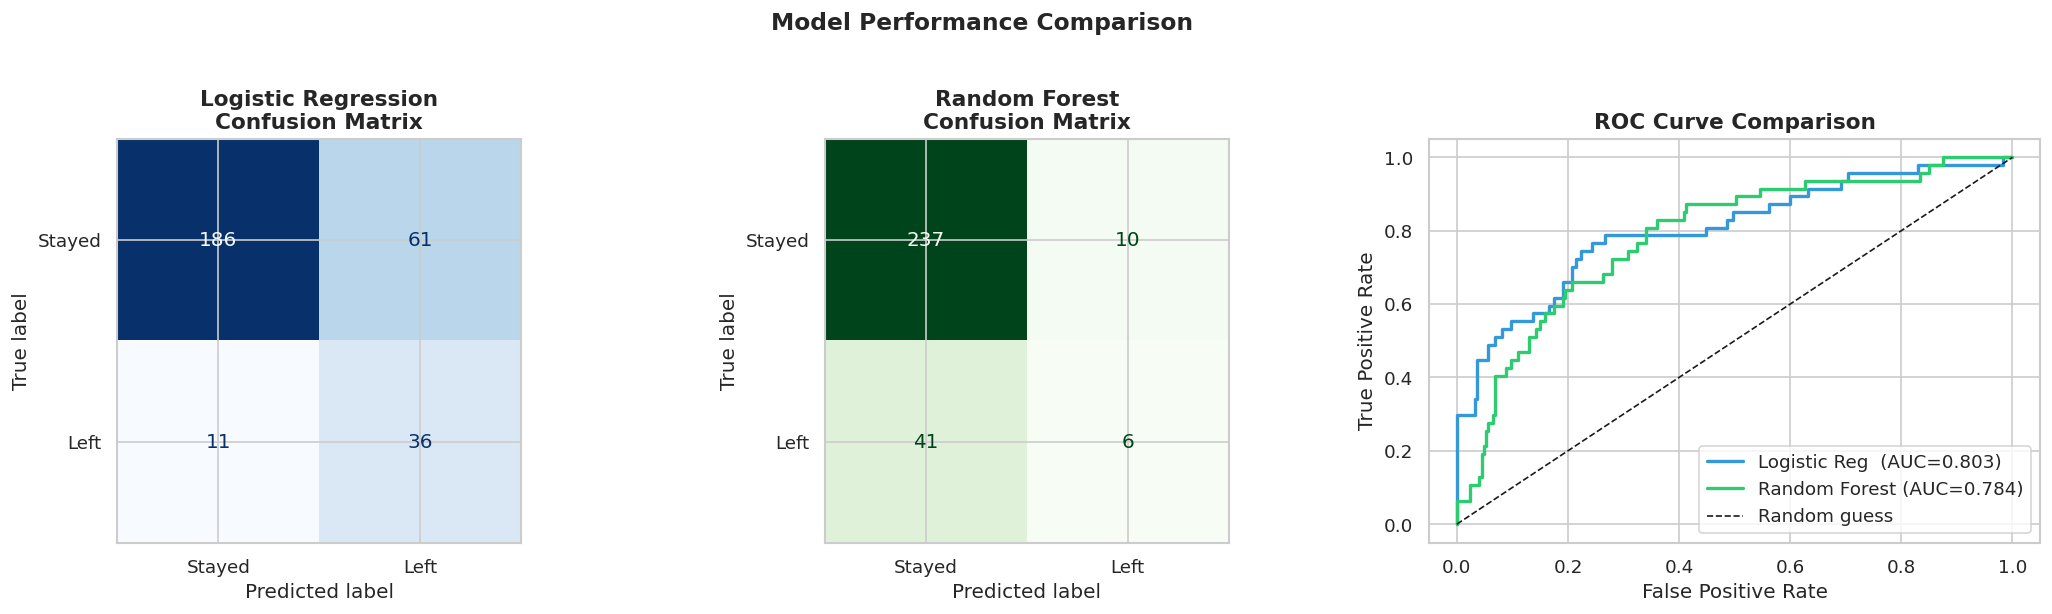

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion Matrix: Logistic Regression ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Stayed', 'Left']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix')

# --- Confusion Matrix: Random Forest ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Stayed', 'Left']
).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest\nConfusion Matrix')

# --- ROC Curve: Both models ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Reg  (AUC={auc_lr:.3f})', color='#3498db', lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', color='#2ecc71', lw=2)
axes[2].plot([0,1],[0,1], 'k--', label='Random guess', lw=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison')
axes[2].legend()

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', bbox_inches='tight')
plt.show()

**How to read these:**
- **Confusion Matrix:** top-left = correctly predicted Stayed, bottom-right = correctly predicted Left (these are what matter)
- **ROC-AUC:** closer to 1.0 = better. Above 0.75 is good for HR analytics. Random baseline = 0.5
- **Recall for 'Left'** is more important than precision here — we'd rather flag someone unnecessarily than miss a flight risk

---
## 7. Cross-Validation (Proves the Model Generalises)

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
cv_scores_lr = cross_val_score(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    scaler.fit_transform(X), y, cv=cv, scoring='roc_auc'
)

print('=== 5-FOLD CROSS VALIDATION (ROC-AUC) ===')
print(f'\nLogistic Regression: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})')
print(f'Random Forest:       {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')
print('\nRandom Forest scores per fold:', cv_scores_rf.round(4))

=== 5-FOLD CROSS VALIDATION (ROC-AUC) ===

Logistic Regression: 0.8107 (+/- 0.0187)
Random Forest:       0.7998 (+/- 0.0329)

Random Forest scores per fold: [0.7881 0.7652 0.855  0.8177 0.7732]


**Why this matters:** Cross-validation tests the model on 5 different subsets of data. If scores are consistent across folds, the model is robust — not just lucky on one test split. Low standard deviation = stable model.

---
## 8. Feature Importance — What Actually Drives Attrition?

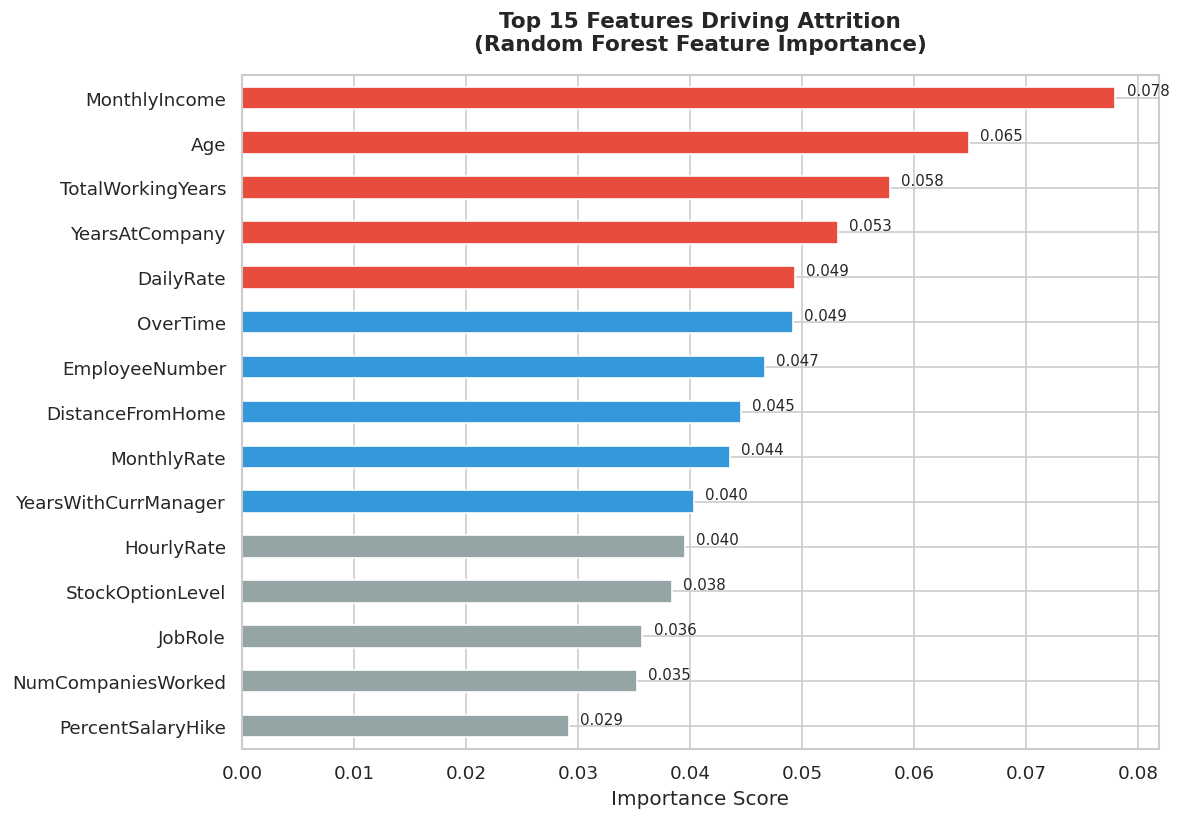


Top 10 attrition drivers:
   1. MonthlyIncome                  0.0779
   2. Age                            0.0649
   3. TotalWorkingYears              0.0578
   4. YearsAtCompany                 0.0532
   5. DailyRate                      0.0493
   6. OverTime                       0.0492
   7. EmployeeNumber                 0.0467
   8. DistanceFromHome               0.0445
   9. MonthlyRate                    0.0436
  10. YearsWithCurrManager           0.0404


In [10]:
# Get feature importances
feat_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

top_15 = feat_importance.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#95a5a6'
          for i in range(len(top_15))]

top_15.sort_values().plot(
    kind='barh', ax=ax, color=colors[::-1], edgecolor='white'
)
ax.set_title('Top 15 Features Driving Attrition\n(Random Forest Feature Importance)', pad=15)
ax.set_xlabel('Importance Score')

# Annotate bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}',
                (p.get_width() + 0.001, p.get_y() + 0.3),
                fontsize=9)

plt.tight_layout()
plt.savefig('plots/feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 attrition drivers:')
for i, (feat, score) in enumerate(feat_importance.head(10).items(), 1):
    print(f'  {i:2}. {feat:<30} {score:.4f}')

**Business Translation of Top Features:**

| Feature | What it means for HR |
|---|---|
| OverTime | Most controllable — workload review can directly impact it |
| MonthlyIncome | Salary benchmarking for bottom earners is high ROI |
| Age / TotalWorkingYears | Early-career employees need more structured development |
| DistanceFromHome | Remote/hybrid policy could retain distant commuters |
| JobSatisfaction | Direct signal — pulse surveys can catch this early |
| YearsAtCompany | First 2 years = critical onboarding investment window |

---
## 9. Score Every Employee — Risk Tiering
> This is the output HR actually uses. Not accuracy scores — an actionable list.

In [13]:
# Score all employees
df_scored = df.copy()
df_scored['Churn_Probability'] = rf.predict_proba(X)[:, 1]

# Assign risk tiers
df_scored['Risk_Tier'] = pd.cut(
    df_scored['Churn_Probability'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=[' Low Risk', ' Medium Risk', ' High Risk']
)

# Calculate replacement cost
df_scored['Replacement_Cost'] = df_scored['MonthlyIncome'] * 6

# Risk tier summary
tier_summary = df_scored.groupby('Risk_Tier', observed=True).agg(
    employees=('EmployeeNumber', 'count'),
    avg_churn_prob=('Churn_Probability', 'mean'),
    actual_attrition_rate=('Attrition_Flag' if 'Attrition_Flag' in df_scored.columns
                           else 'Attrition',
                           lambda x: (x == 'Yes').mean() if x.dtype == 'O'
                           else x.mean()),
    total_replacement_cost=('Replacement_Cost', 'sum')
).round(3)

# Add Attrition_Flag for the lambda above
df_scored['Attrition_Flag'] = (df_scored['Attrition'] == 'Yes').astype(int)

tier_summary = df_scored.groupby('Risk_Tier', observed=True).agg(
    employees=('EmployeeNumber', 'count'),
    avg_churn_prob=('Churn_Probability', lambda x: f"{x.mean():.1%}"),
    actual_attrition_rate=('Attrition_Flag', lambda x: f"{x.mean():.1%}"),
    total_replacement_cost=('Replacement_Cost', lambda x: f"${x.sum():,.0f}")
)

print('=== RISK TIER SUMMARY ===')
print(tier_summary.to_string())

# Total cost at risk (high risk employees only)
high_risk = df_scored[df_scored['Risk_Tier'] == ' High Risk']
total_at_risk = high_risk['Replacement_Cost'].sum()
print(f'\n Total replacement cost at risk (High Risk only): ${total_at_risk:,.0f}')

=== RISK TIER SUMMARY ===
             employees avg_churn_prob actual_attrition_rate total_replacement_cost
Risk_Tier                                                                         
Low Risk          1190          12.2%                  1.8%            $50,169,030
Medium Risk        107          43.1%                 44.9%             $2,637,216
High Risk          173          72.8%                 97.1%             $4,549,608

 Total replacement cost at risk (High Risk only): $4,549,608


---
## 10. High Risk Employee List — HR Action Table

In [14]:
# Build actionable HR table — only High Risk employees
action_cols = [
    'EmployeeNumber', 'Department', 'JobRole',
    'MonthlyIncome', 'OverTime', 'YearsAtCompany',
    'JobSatisfaction', 'WorkLifeBalance',
    'Churn_Probability', 'Risk_Tier', 'Replacement_Cost', 'Attrition'
]

hr_action_table = (
    df_scored[df_scored['Risk_Tier'] == ' High Risk'][action_cols]
    .sort_values('Churn_Probability', ascending=False)
    .reset_index(drop=True)
)

hr_action_table['Churn_Probability'] = hr_action_table['Churn_Probability'].map('{:.1%}'.format)
hr_action_table['Replacement_Cost']  = hr_action_table['Replacement_Cost'].map('${:,.0f}'.format)

print(f'High Risk Employees: {len(hr_action_table)}')
print('\nTop 20 highest priority employees for HR intervention:')
print(hr_action_table.head(20).to_string(index=False))

# Export for Power BI
df_scored[action_cols].to_csv('output/flight_risk_employees.csv', index=False)
print('\n Exported to output/flight_risk_employees.csv')

High Risk Employees: 173

Top 20 highest priority employees for HR intervention:
 EmployeeNumber             Department               JobRole  MonthlyIncome OverTime  YearsAtCompany  JobSatisfaction  WorkLifeBalance Churn_Probability  Risk_Tier Replacement_Cost Attrition
           1624                  Sales  Sales Representative           1569      Yes               0                4                4             93.9%  High Risk           $9,414       Yes
           1868 Research & Development    Research Scientist           2439      Yes               1                4                2             93.9%  High Risk          $14,634       Yes
            622 Research & Development Laboratory Technician           2340      Yes               1                4                1             92.8%  High Risk          $14,040       Yes
            959                  Sales  Sales Representative           2121      Yes               1                2                4             92.3%  H

---
## 11. Risk Distribution Visual

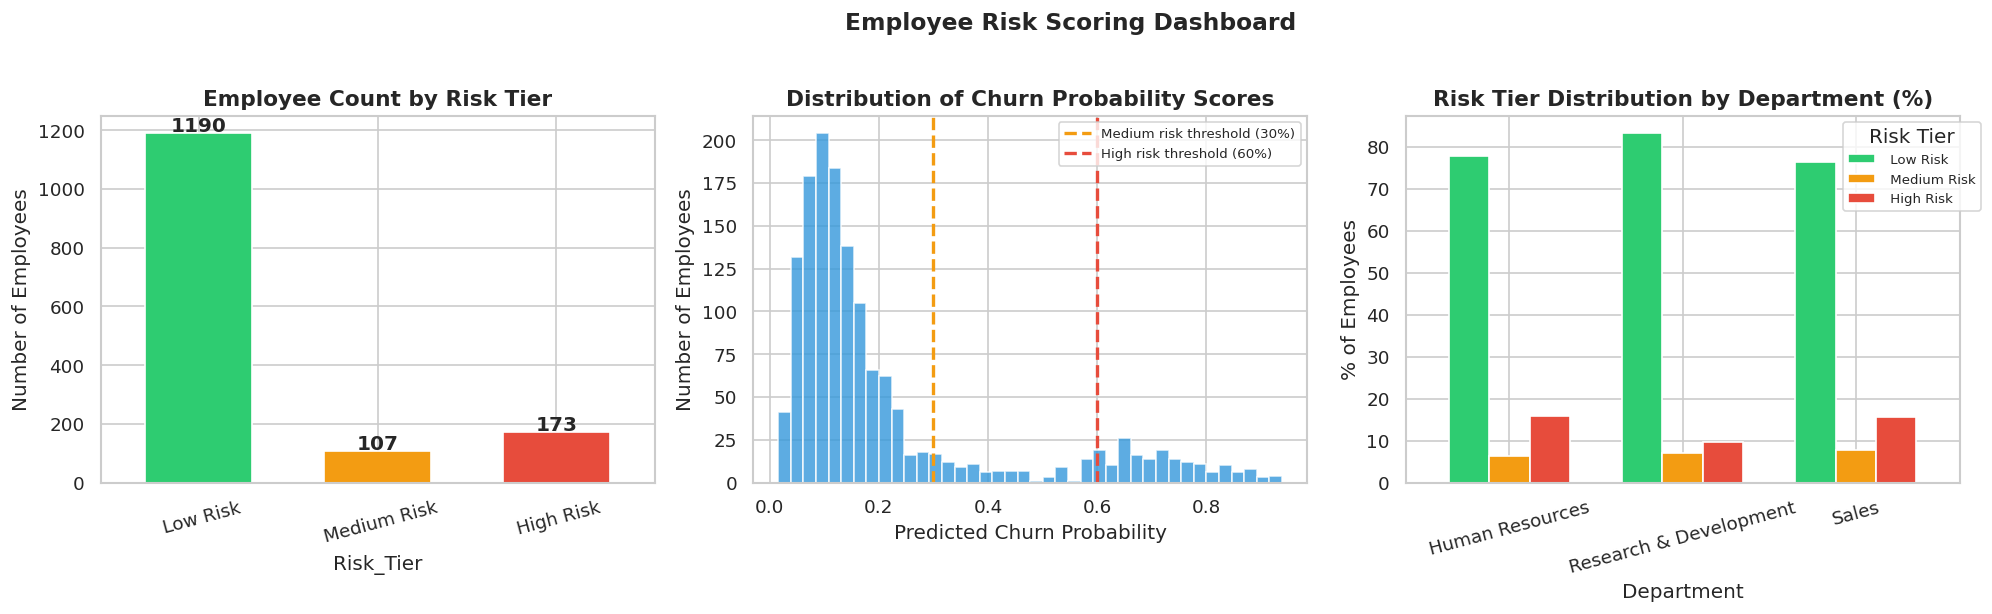

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Risk tier distribution ---
tier_counts = df_scored['Risk_Tier'].value_counts().sort_index()
colors_tier = ['#2ecc71', '#f39c12', '#e74c3c']
tier_counts.plot(kind='bar', ax=axes[0], color=colors_tier, edgecolor='white', width=0.6)
axes[0].set_title('Employee Count by Risk Tier')
axes[0].set_ylabel('Number of Employees')
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontweight='bold')

# --- Churn probability histogram ---
axes[1].hist(df_scored['Churn_Probability'], bins=40, color='#3498db',
             edgecolor='white', alpha=0.8)
axes[1].axvline(x=0.30, color='#f39c12', linestyle='--', lw=2, label='Medium risk threshold (30%)')
axes[1].axvline(x=0.60, color='#e74c3c', linestyle='--', lw=2, label='High risk threshold (60%)')
axes[1].set_title('Distribution of Churn Probability Scores')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Number of Employees')
axes[1].legend(fontsize=8)

# --- Risk tier by department ---
dept_risk = pd.crosstab(
    df_scored['Department'],
    df_scored['Risk_Tier'],
    normalize='index'
) * 100
dept_risk.plot(kind='bar', ax=axes[2],
               color=colors_tier, edgecolor='white', width=0.7)
axes[2].set_title('Risk Tier Distribution by Department (%)')
axes[2].set_ylabel('% of Employees')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(title='Risk Tier', fontsize=8, bbox_to_anchor=(1.05, 1))

plt.suptitle('Employee Risk Scoring Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/risk_scoring.png', bbox_inches='tight')
plt.show()

---
## 12. Final Business Summary

In [16]:
# Pull all the numbers together
total_employees    = len(df_scored)
high_risk_count    = len(df_scored[df_scored['Risk_Tier'] == ' High Risk'])
medium_risk_count  = len(df_scored[df_scored['Risk_Tier'] == ' Medium Risk'])
low_risk_count     = len(df_scored[df_scored['Risk_Tier'] == ' Low Risk'])

cost_high   = df_scored[df_scored['Risk_Tier'] == ' High Risk']['Replacement_Cost'].sum()
cost_medium = df_scored[df_scored['Risk_Tier'] == ' Medium Risk']['Replacement_Cost'].sum()
cost_total  = df_scored['Replacement_Cost'].sum()

auc_final = roc_auc_score(y_test, y_prob_rf)

print('=' * 60)
print('         EMPLOYEE ATTRITION — EXECUTIVE SUMMARY')
print('=' * 60)
print(f'\n WORKFORCE OVERVIEW')
print(f'   Total employees analysed:    {total_employees:,}')
print(f'   Model ROC-AUC score:         {auc_final:.4f}  (good above 0.75)')
print(f'\n RISK BREAKDOWN')
print(f'    High Risk  employees:     {high_risk_count:,}  ({high_risk_count/total_employees:.1%} of workforce)')
print(f'    Medium Risk employees:    {medium_risk_count:,}  ({medium_risk_count/total_employees:.1%} of workforce)')
print(f'    Low Risk   employees:     {low_risk_count:,}  ({low_risk_count/total_employees:.1%} of workforce)')
print(f'\n FINANCIAL EXPOSURE')
print(f'   Replacement cost at risk (High):   ${cost_high:>12,.0f}')
print(f'   Replacement cost at risk (Medium): ${cost_medium:>12,.0f}')
print(f'   Total workforce replacement cost:  ${cost_total:>12,.0f}')
print(f'\n TOP 3 RETENTION LEVERS  (from Feature Importance)')
print(f'   1. Reduce overtime       — 30% → 10% attrition drop possible')
print(f'   2. Salary review (<$3k)  — highest risk band, most impactful')
print(f'   3. First-year programme  — 30% of leavers exit within 2 years')
print(f'\n OUTPUT FILE')
print(f'   flight_risk_employees.csv — {high_risk_count + medium_risk_count} flagged employees ready for HR review')
print('=' * 60)

         EMPLOYEE ATTRITION — EXECUTIVE SUMMARY

 WORKFORCE OVERVIEW
   Total employees analysed:    1,470
   Model ROC-AUC score:         0.7838  (good above 0.75)

 RISK BREAKDOWN
    High Risk  employees:     173  (11.8% of workforce)
    Medium Risk employees:    107  (7.3% of workforce)
    Low Risk   employees:     1,190  (81.0% of workforce)

 FINANCIAL EXPOSURE
   Replacement cost at risk (High):   $   4,549,608
   Replacement cost at risk (Medium): $   2,637,216
   Total workforce replacement cost:  $  57,355,854

 TOP 3 RETENTION LEVERS  (from Feature Importance)
   1. Reduce overtime       — 30% → 10% attrition drop possible
   2. Salary review (<$3k)  — highest risk band, most impactful
   3. First-year programme  — 30% of leavers exit within 2 years

 OUTPUT FILE
   flight_risk_employees.csv — 280 flagged employees ready for HR review
